# Explaining a Neural Network with LIME

This notebook trains a simple `MLPClassifier` on the scikit-learn **Breast Cancer** dataset and then uses **LIME** (Local Interpretable Model-agnostic Explanations) to explain its predictions.

**Workflow:**
1. Load and preprocess the data.
2. Train an MLP classifier (the "black box").
3. Build a LIME tabular explainer and use it to explain individual predictions.
4. Persist the trained model and explanations to disk, then reload them.
5. Aggregate LIME explanations across the whole test set to get a global view of feature importance.

In [58]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from matplotlib import pyplot as plt
import dill
from lime.lime_tabular import LimeTabularExplainer
import warnings

warnings.filterwarnings('ignore')

SEED = 2025

## 1. Load & Prepare the Data

Load the Breast Cancer dataset, split it into train/test sets, and standardize the features with `StandardScaler` (LIME's perturbation sampling assumes features are on comparable scales).

In [59]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 2. Train the Black-Box Model

Fit a small `MLPClassifier` (one hidden layer of 50 units) on the training data. LIME treats this model as a black box — it only needs access to `predict_proba`.

In [60]:
mlp = MLPClassifier(hidden_layer_sizes=(50,), activation='relu', solver='adam', max_iter=1000, random_state=SEED)
mlp.fit(X_train, y_train)

train_accuracy = accuracy_score(y_train, mlp.predict(X_train))
test_accuracy = accuracy_score(y_test, mlp.predict(X_test))
print(f"Train Accuracy: {train_accuracy:.4f}   |   Test Accuracy: {test_accuracy:.4f}")

Train Accuracy: 0.9956   |   Test Accuracy: 0.9825


## 3. Configure the LIME Explainer

Create a `LimeTabularExplainer` fitted on the training data distribution. It will generate local, interpretable approximations of the MLP's decision boundary around individual instances.

In [61]:
explainer = LimeTabularExplainer(X_train,
                                 mode='classification',
                                 training_labels=y_train,
                                 feature_names=data.feature_names,
                                 class_names=data.target_names,
                                 discretize_continuous=True)

## 4. Explain a Single Test Instance

Pick one test instance (index 25) and ask LIME to explain the MLP's prediction for it, keeping the top 10 most influential features.

In [62]:
instance_idx = 25
instance = X_test[instance_idx]

exp = explainer.explain_instance(data_row=instance,
                                 predict_fn=mlp.predict_proba,
                                 num_features=10,
                                 top_labels=1)

## 5. Save Artifacts for Reuse

Persist the preprocessed test set, the trained model, the explainer, and the single-instance explanation to `_aux/` with `dill`, so they can be reloaded later without retraining.

In [63]:
import os

os.makedirs('_aux', exist_ok=True)

np.save('_aux/X_test_prepr', X_test)
dill.dump(mlp, open('_aux/MLP_model.pkl', 'wb'))
dill.dump(explainer, open('_aux/lime.pkl', 'wb'))
dill.dump(exp, open('_aux/lime_single_'+str(instance_idx)+'.pkl', 'wb'))

## 6. Reload Artifacts

Reload everything from disk, simulating a fresh session that only needs the saved artifacts (no retraining required).

In [64]:
X_test = np.load('_aux/X_test_prepr.npy')
mlp = dill.load(open('_aux/MLP_model.pkl', 'rb'))
explainer = dill.load(open('_aux/lime.pkl', 'rb'))
exp = dill.load(open('_aux/lime_single_25.pkl', 'rb'))

## 7. Inspect & Visualize the Explanation

Look at the explanation as a list of `(feature, weight)` pairs, then plot it with LIME's built-in bar chart.

In [65]:
exp.as_list()

[('worst smoothness > 0.56', -0.16996225348920366),
 ('worst texture <= -0.77', 0.15881171285565546),
 ('worst concavity <= -0.72', 0.13041321120613675),
 ('compactness error <= -0.70', -0.10091141861341779),
 ('mean texture <= -0.71', 0.09193539506011833),
 ('-0.72 < mean concave points <= -0.39', 0.07534173291236412),
 ('-0.58 < fractal dimension error <= -0.21', -0.061303628803938616),
 ('-0.63 < worst area <= -0.32', 0.05786738171569412),
 ('-0.73 < mean concavity <= -0.34', 0.0572514906297836),
 ('-0.70 < worst fractal dimension <= -0.24', 0.05696700341583219)]

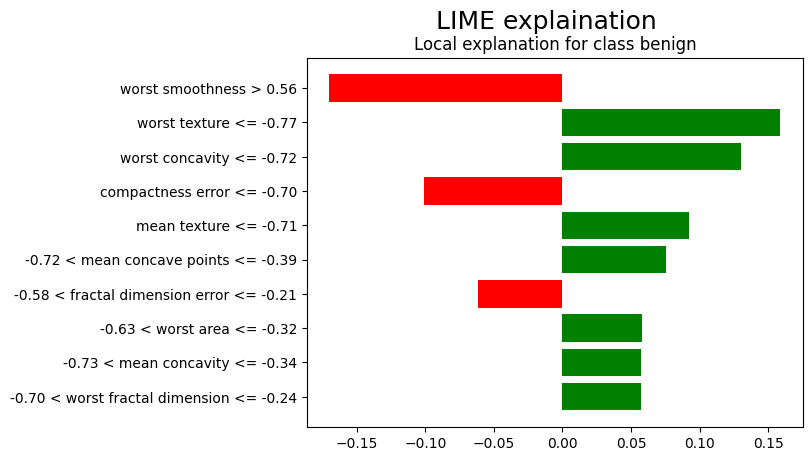

In [66]:
fig = exp.as_pyplot_figure()
fig.suptitle('LIME explaination', fontsize=18)
plt.show()

## 8. Explanation Stability Across Runs

LIME explanations are based on randomly sampled perturbations around the instance, so re-running `explain_instance` on the same data point can produce slightly different feature weights. The two explanations below are computed independently for the same instance (index 25) to illustrate this variability.

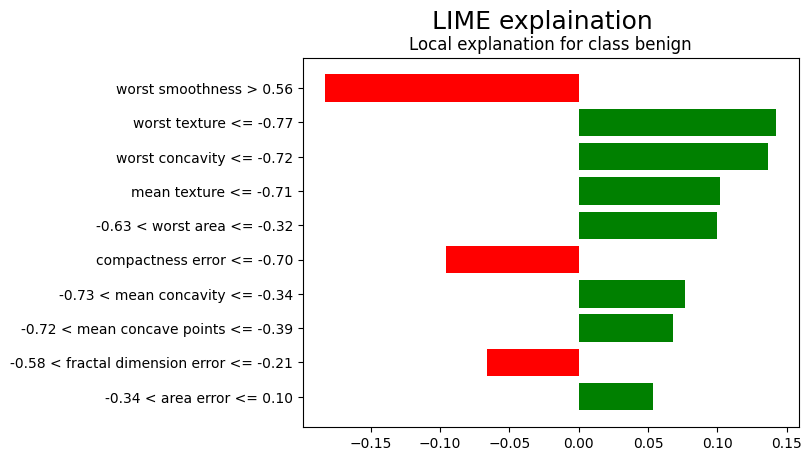

In [67]:
exp25a = explainer.explain_instance(data_row=X_test[25],
                                    predict_fn=mlp.predict_proba,
                                    num_features=10,
                                    top_labels=1)

fig = exp25a.as_pyplot_figure()
fig.suptitle('LIME explaination', fontsize=18)
plt.show()

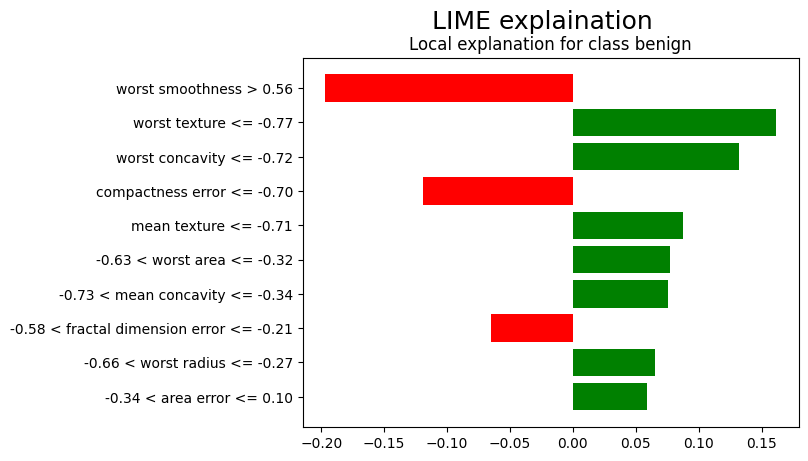

In [68]:
exp25b = explainer.explain_instance(data_row=X_test[25],
                                    predict_fn=mlp.predict_proba,
                                    num_features=10,
                                    top_labels=1)

fig = exp25b.as_pyplot_figure()
fig.suptitle('LIME explaination', fontsize=18)
plt.show()

## 9. Explanation as a Feature-Weight Map

`as_map()` returns the explanation as `{class_label: [(feature_index, weight), ...]}`, which is easier to consume programmatically than the plotting helpers above.

In [69]:
explainer.explain_instance(data_row=X_test[25],
                            predict_fn=mlp.predict_proba,
                            num_features=10,
                            top_labels=1).as_map()

{np.int64(1): [(np.int64(24), np.float64(-0.17808632128196317)),
  (np.int64(21), np.float64(0.17324223695197463)),
  (np.int64(26), np.float64(0.1193259944588843)),
  (np.int64(15), np.float64(-0.11104801932681725)),
  (np.int64(1), np.float64(0.09467401258884546)),
  (np.int64(7), np.float64(0.0930935304483664)),
  (np.int64(19), np.float64(-0.08561337457811481)),
  (np.int64(6), np.float64(0.06399478277885562)),
  (np.int64(3), np.float64(0.06376595093728336)),
  (np.int64(23), np.float64(0.05758379170191533))]}

## 10. Aggregate LIME Explanations Across the Test Set

To move from a *local* explanation (single instance) to a *global* view of feature importance, compute a LIME explanation for every test instance and collect the per-feature weights:

- `do_lime` wraps `explain_instance` + `as_map()` for a given test index.
- `all_exp` holds the raw map-form explanation for every test instance.
- `aggregated_scores` collects, for each feature index, the list of weights it received across all explanations.

In [70]:
do_lime = lambda x : explainer.explain_instance(data_row=X_test[x],
                            predict_fn=mlp.predict_proba,
                            num_features=10,
                            top_labels=1).as_map()

In [71]:
all_exp = [do_lime(i) for i in range(X_test.shape[0])]

In [72]:
aggregated_scores = {i:[] for i in range(X_test.shape[1])}
for exp in all_exp:
    data = exp[0] if 0 in exp else exp[1]
    for fnum, score in data:
        aggregated_scores[fnum] = aggregated_scores[fnum] + [score]                                       

In [73]:
all_exp[0]

{np.int64(1): [(np.int64(21), np.float64(0.15781954305413212)),
  (np.int64(1), np.float64(0.09591138779011735)),
  (np.int64(7), np.float64(0.07993120916904688)),
  (np.int64(23), np.float64(0.0783086514072996)),
  (np.int64(6), np.float64(0.07668276918027431)),
  (np.int64(27), np.float64(0.05598422724340007)),
  (np.int64(24), np.float64(0.055620464420061876)),
  (np.int64(13), np.float64(0.055244695587479964)),
  (np.int64(20), np.float64(0.053311258995301106)),
  (np.int64(26), np.float64(0.05258555948318444))]}

## 11. Global Feature Importance Plot

Summarize each feature's aggregated importance as the sum of absolute LIME weights across the test set, then plot it against the original feature names.

In [74]:
fnames = load_breast_cancer()['feature_names']

In [75]:
vals_to_plot = [np.sum(np.abs(v)) for v in aggregated_scores.values()]

Text(0.5, 1.0, 'LIME scores across test set')

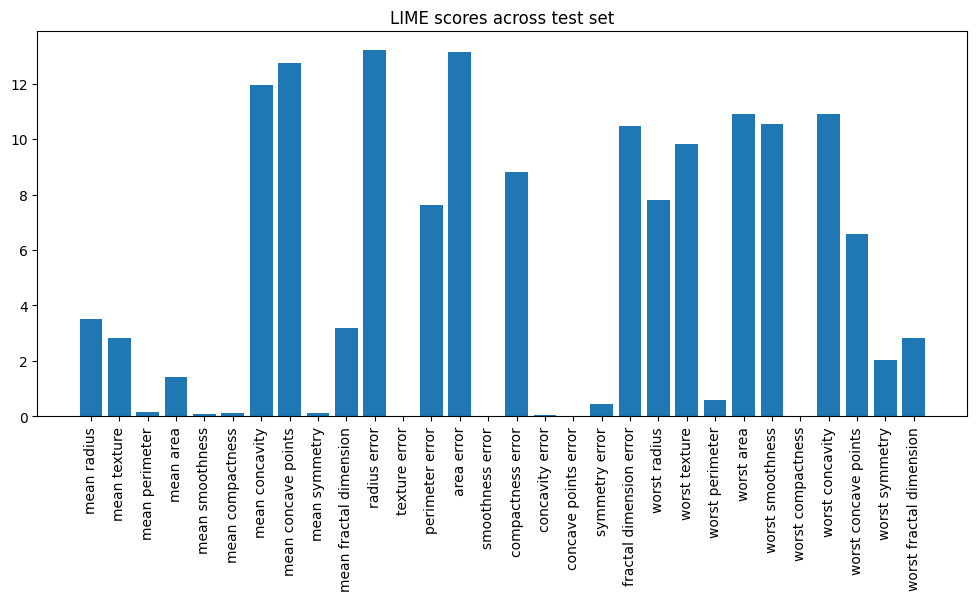

In [76]:
plt.figure(figsize=(12, 5))
plt.bar(fnames, vals_to_plot)
plt.xticks(rotation=90)
plt.title('LIME scores across test set')